# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [3]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv.csv", delimiter=',')

df.head(10)


,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [16]:
# criado DF da media e agrupamentos de produtos e ordenamento
Media = df.groupby('Categoria')['Preco_Normal'].mean().reset_index().sort_values(by='Preco_Normal', ascending=False)
# criado DF da mediana e agrupamentos de produtos e ordenamento
Mediana = df.groupby('Categoria')['Preco_Normal'].median().reset_index().sort_values(by='Preco_Normal', ascending=False)
# DF comparativo entre media e mediana
Comparativo = Media.merge(Mediana, on="Categoria")
Comparativo.columns = ['Categoria', 'Media', 'Mediana'] # renomeia colunas do comparativo
Comparativo.head(10)

,Categoria,Media,Mediana
0,comidas-preparadas,3095.043478,3290.0
1,lacteos,2385.219239,989.0
2,congelados,2108.042553,1519.0
3,belleza-y-cuidado-personal,1783.556485,1569.0
4,frutas,1724.473684,1195.0
5,verduras,1343.296875,1180.0
6,instantaneos-y-sopas,765.491228,439.0


In [17]:
# identificação das categorias que tem um valor diferentes da media e mediana
Comparativo['Resultado'] = 'Igual' # Valor padrão
Comparativo.loc[Comparativo['Media'] > Comparativo['Mediana'], 'Resultado'] = 'Media acima'
Comparativo.loc[Comparativo['Media'] < Comparativo['Mediana'], 'Resultado'] = 'Media abaixo'
Comparativo.head(10)

,Categoria,Media,Mediana,Resultado
0,comidas-preparadas,3095.043478,3290.0,Media abaixo
1,lacteos,2385.219239,989.0,Media acima
2,congelados,2108.042553,1519.0,Media acima
3,belleza-y-cuidado-personal,1783.556485,1569.0,Media acima
4,frutas,1724.473684,1195.0,Media acima
5,verduras,1343.296875,1180.0,Media acima
6,instantaneos-y-sopas,765.491228,439.0,Media acima


Digite aqui as categorias:
Comidas-preparadas,
lacteos,
congelados,
belleza-u-cuidado-personal,
frutas,
verduras
instantaneos-y-sopas

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [32]:
#calculo do Desvio padrão do items por categoria
Desvio = df.groupby('Categoria')['Preco_Normal'].std().reset_index().sort_values('Preco_Normal', ascending=False)
Desvio.columns = ['Categoria', 'Desvio_Padrao'] # renomeia colunas

Desvio.head(10)

,Categoria,Desvio_Padrao
5,lacteos,3925.816164
0,belleza-y-cuidado-personal,2210.041719
2,congelados,2111.539896
1,comidas-preparadas,2019.911428
3,frutas,1639.151114
4,instantaneos-y-sopas,1170.232869
6,verduras,1012.699625


Digite nesse campo o comportamento que você identificou.

que todos os produtos apresentam um desvio padrão alto porem os grupos de maior varibilidade de items apresentam um desvio maior, o que ocorre com a Categoria de "Lacteos", apresentando o maior desvio padrão e um cofieciente de variação superior a 130%.

## 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

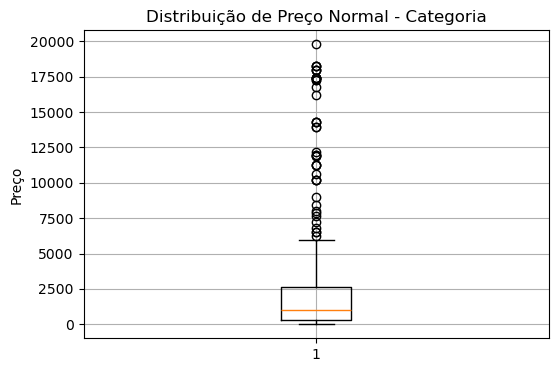

In [33]:
# localizar e filtrar por categoria
Dados_por_Categoria = df.loc[df['Categoria'] == 'lacteos']

#bloxplot
plt.figure(figsize=(6,4))
plt.boxplot(Dados_por_Categoria['Preco_Normal'])
plt.title('Distribuição de Preço Normal - Categoria')
plt.ylabel('Preço')
plt.grid()
plt.show()


Verificamos que os 50% centrais estão localizados nos menores valores de preços aproximada 2500, porem possui items com outliers muito altos, que indica ou valores erroneos ou items muito diversificados dentro desta categorias de Laticinios como por items de luxo sobre acima dos 2500 e se aproxima dos valores de 20000.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

<function matplotlib.pyplot.show(close=None, block=None)>

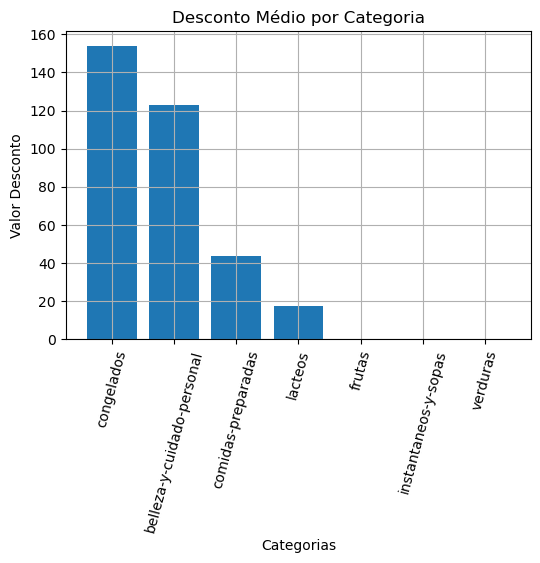

In [35]:
# agrupamento e calculo de média dos descontos
Media_Desc = df.groupby('Categoria')['Desconto'].mean().reset_index().sort_values('Desconto', ascending=False)
# grafico de barras
plt.figure(figsize=(6,4))
plt.bar(Media_Desc['Categoria'],Media_Desc['Desconto'])
plt.title('Desconto Médio por Categoria')
plt.xlabel('Categorias')
plt.xticks(rotation=75)
plt.ylabel('Valor Desconto')
plt.grid()
plt.show


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

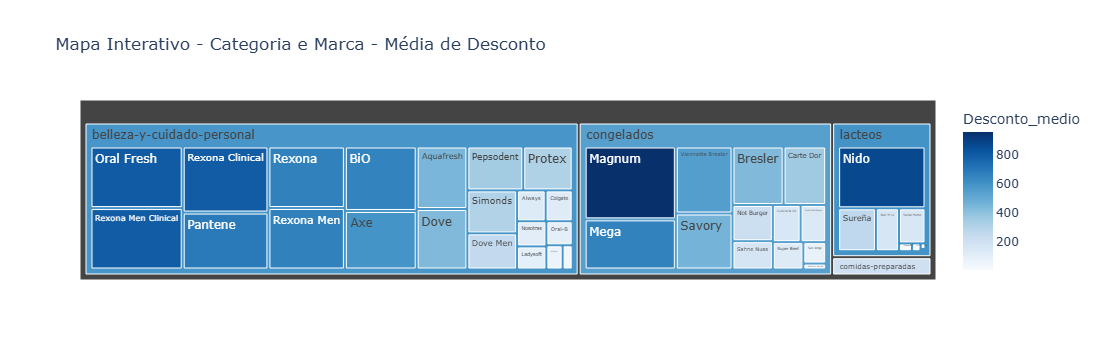

In [56]:
# agrupamento Categorias, media desconto, marca
df_mapa = df.groupby(['Categoria','Marca'])['Desconto'].mean().reset_index().sort_values('Desconto', ascending=False)
df_mapa.rename(columns={'Desconto':'Desconto_medio'}, inplace=True)

# grafico de mapa
fig = px.treemap(df_mapa,
                 path=['Categoria','Marca'],    # hierarquia: Categoria -> Marca
                 values='Desconto_medio',        # tamanho bloco = média de desconto
                 color='Desconto_medio',         # Cor representa desconto
                 color_continuous_scale='Blues',  # Escala de cor de intesidade
                 title= 'Mapa Interativo - Categoria e Marca - Média de Desconto')
fig.show()